In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# CIFAR-10 (32x32)

# Transforms definitions
train_transform = transforms.Compose([
    transforms.Resize(224), # upscale [32,32] -> [224, 224]
    transforms.RandomHorizontalFlip(), # change right and left
    transforms.ToTensor(), # 0-255 -> 0-1.0
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)) # mean(s) are all 0.5, std are all 0.5
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# Dataset loading
os.makedirs('./data', exist_ok=True)
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# DataLoader definitinos
BATCH_SIZE = 128
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True # GPU transportation speed up
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

shape torch.Size([128, 3, 224, 224])


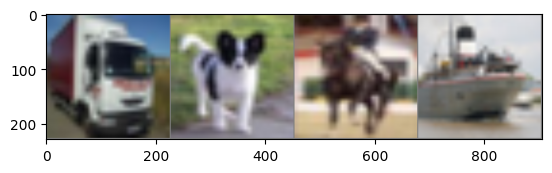

labels : truck dog horse ship


In [3]:
def imshow(img):
    img = img / 2 + 0.5 # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.show()

# get 1 batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print('shape', images.shape)
imshow(torchvision.utils.make_grid(images[:4]))
print(f'labels : {" ".join(classes[labels[j]] for j in range(4))}')

In [4]:
from vit import VisionTransformer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer(
    img_size=224,
    patch_size=16,
    in_chans=3,
    num_classes=10,
    embed_dim=192,
    depth=6,
    num_heads=6,
    mlp_ratio=4, # in mlp use 4x hedden dim
    qkv_bias=True,
    drop_rate=0.,
    drop_path_rate=0.1
).to(device)

print(f'Model created and moved to {device}')

Model created and moved to cuda


In [5]:
# define loss function
criterion = torch.nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)

# lr scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [6]:
# training setting
# AMP mix presicion
scaler = torch.amp.GradScaler()

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # mix precision
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        # backpropagation with scalled grad
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(dataloader), 100. * correct / total
            

In [7]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(dataloader), 100. * correct / total

In [8]:
# train
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    scheduler.step() # update next learning rate

    print(f'Epoch {epoch+1}/{EPOCHS}')
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%')
    print('-' * 30)

Epoch 1/10
Train Loss: 1.8144 | Train Acc: 32.11%
Test Loss: 1.5888 | Test Acc: 41.14%
------------------------------
Epoch 2/10
Train Loss: 1.5049 | Train Acc: 44.80%
Test Loss: 1.4137 | Test Acc: 48.47%
------------------------------
Epoch 3/10
Train Loss: 1.3460 | Train Acc: 50.86%
Test Loss: 1.3013 | Test Acc: 51.98%
------------------------------
Epoch 4/10
Train Loss: 1.2238 | Train Acc: 55.57%
Test Loss: 1.1787 | Test Acc: 57.30%
------------------------------
Epoch 5/10
Train Loss: 1.1040 | Train Acc: 60.21%
Test Loss: 1.1250 | Test Acc: 58.80%
------------------------------
Epoch 6/10
Train Loss: 1.0128 | Train Acc: 63.54%
Test Loss: 1.0825 | Test Acc: 61.05%
------------------------------
Epoch 7/10
Train Loss: 0.9203 | Train Acc: 67.07%
Test Loss: 0.9620 | Test Acc: 65.75%
------------------------------
Epoch 8/10
Train Loss: 0.8308 | Train Acc: 70.17%
Test Loss: 0.9052 | Test Acc: 67.20%
------------------------------
Epoch 9/10
Train Loss: 0.7500 | Train Acc: 73.39%
Test L